<a href="https://colab.research.google.com/github/abhinavverma0907/SOC-2026-Encryption-and-Decryption/blob/main/Week_3/Assignment/Week_3_Substitution_Cipher_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import random
import urllib.request
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cpu


In [28]:
alphabet = ['a','b','c','d','e','f','g','h','i','j','k','l','m',
            'n','o','p','q','r','s','t','u','v','w','x','y','z',
            ' ','.', ',',';',':','/', '@']

N = len(alphabet)
char_to_idx = {ch: i for i, ch in enumerate(alphabet)}

random.seed(42)
permutations = []
for _ in range(3):
    perm = list(range(N))
    random.shuffle(perm)
    permutations.append(perm)

print(f"Created {len(permutations)} substitution ciphers")
print("Permutation 0 (first 10 mappings):")
for i in range(10):
    print(f"  '{alphabet[i]}' → '{alphabet[permutations[0][i]]}'")

Created 3 substitution ciphers
Permutation 0 (first 10 mappings):
  'a' → '.'
  'b' → 'f'
  'c' → 'l'
  'd' → 'q'
  'e' → ' '
  'f' → 'm'
  'g' → 'u'
  'h' → 'p'
  'i' → 'k'
  'j' → 'o'


In [29]:
def substitute_encrypt(text, perm):
    result = ""
    for ch in text:
        if ch in char_to_idx:
            result += alphabet[perm[char_to_idx[ch]]]
    return result

test = "hello world"
encrypted = substitute_encrypt(test, permutations[0])
print(f"Original:  {test}")
print(f"Encrypted: {encrypted}")

Original:  hello world
Encrypted: p wwyeryawq


In [30]:
url = "https://www.gutenberg.org/files/1342/1342-0.txt"
with urllib.request.urlopen(url) as f:
    raw_text = f.read().decode('utf-8')

def clean_text(text):
    text = text.lower()
    return "".join(ch for ch in text if ch in char_to_idx)

text = clean_text(raw_text)
print(f"Clean text length: {len(text)} chars")
print("Sample:", text[:80])

Clean text length: 705409 chars
Sample:  start of the project gutenberg ebook                              illustration:


In [31]:
M = 20

X_data = []
y_data = []

chunks = [text[i:i+M] for i in range(0, len(text)-M, M)]
print(f"Total chunks: {len(chunks)}")

for chunk in chunks:
    if len(chunk) < M:
        continue
    perm_idx = random.randint(0, 2)
    encrypted = substitute_encrypt(chunk, permutations[perm_idx])
    encoded = [char_to_idx[ch] for ch in encrypted]
    X_data.append(encoded)
    y_data.append(perm_idx)

X_data = np.array(X_data, dtype=np.int64)
y_data = np.array(y_data, dtype=np.int64)

print(f"Dataset size: {len(X_data)}")
print(f"Label distribution: {np.bincount(y_data)}")

Total chunks: 35270
Dataset size: 35270
Label distribution: [11847 11700 11723]


In [32]:
class SubDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.LongTensor(X)
        self.y = torch.LongTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

split = int(0.8 * len(X_data))
idx = np.random.permutation(len(X_data))

train_loader = DataLoader(
    SubDataset(X_data[idx[:split]], y_data[idx[:split]]),
    batch_size=128, shuffle=True
)
test_loader = DataLoader(
    SubDataset(X_data[idx[split:]], y_data[idx[split:]]),
    batch_size=128, shuffle=False
)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 221
Test batches:  56


In [33]:
class SubstitutionRNN(nn.Module):
    def __init__(self, vocab_size=33, embed_dim=32, hidden_size=128, num_classes=3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.RNN(embed_dim, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        out, hidden = self.rnn(embedded)
        pooled = torch.max(out, dim=1).values
        return self.fc(pooled)

model = SubstitutionRNN().to(device)
print(model)
print(f"Parameters: {sum(p.numel() for p in model.parameters())}")

SubstitutionRNN(
  (embedding): Embedding(33, 32)
  (rnn): RNN(32, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=3, bias=True)
)
Parameters: 22179


In [34]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 10

train_losses = []
test_accuracies = []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    model.eval()
    correct = total = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            output = model(X_batch)
            _, predicted = torch.max(output, 1)
            correct += (predicted == y_batch).sum().item()
            total += len(y_batch)

    acc = correct / total * 100
    test_accuracies.append(acc)
    print(f"Epoch {epoch+1:2d}/{epochs} | Loss: {avg_loss:.4f} | Accuracy: {acc:.2f}%")

print("\nDone! (Random guessing = 33.33%)")

Epoch  1/10 | Loss: 0.1291 | Accuracy: 99.73%
Epoch  2/10 | Loss: 0.0117 | Accuracy: 99.80%
Epoch  3/10 | Loss: 0.0074 | Accuracy: 99.83%
Epoch  4/10 | Loss: 0.0050 | Accuracy: 99.86%
Epoch  5/10 | Loss: 0.0033 | Accuracy: 99.93%
Epoch  6/10 | Loss: 0.0029 | Accuracy: 99.96%
Epoch  7/10 | Loss: 0.0017 | Accuracy: 99.91%
Epoch  8/10 | Loss: 0.0019 | Accuracy: 99.97%
Epoch  9/10 | Loss: 0.0018 | Accuracy: 99.87%
Epoch 10/10 | Loss: 0.0012 | Accuracy: 99.91%

Done! (Random guessing = 33.33%)


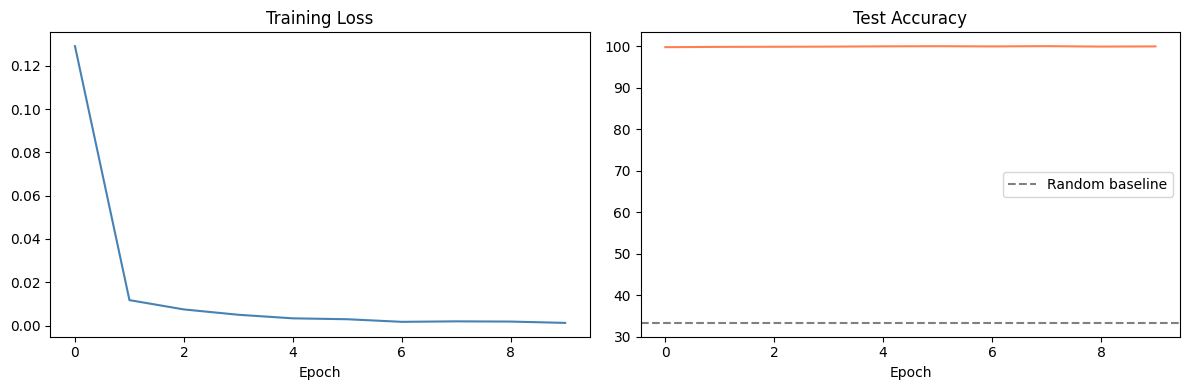

In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, color='steelblue')
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')

ax2.plot(test_accuracies, color='coral')
ax2.axhline(y=33.33, color='gray', linestyle='--', label='Random baseline')
ax2.set_title('Test Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

In [36]:
def predict_cipher(text):
    cleaned = clean_text(text)[:M]
    if len(cleaned) < M:
        print("Need at least 20 characters")
        return

    encoded = torch.LongTensor([[char_to_idx[ch] for ch in cleaned]]).to(device)

    model.eval()
    with torch.no_grad():
        output = model(encoded)
        predicted_perm = torch.argmax(output).item()

    print(f"Input (encrypted): '{cleaned}'")
    print(f"Predicted permutation: {predicted_perm}")
    return predicted_perm

test_plain = "the quick brown fox jumps over"
test_perm_idx = 1
test_cipher = substitute_encrypt(clean_text(test_plain), permutations[test_perm_idx])

print(f"Original:  {test_plain}")
print(f"Encrypted: {test_cipher}")
print()
predicted = predict_cipher(test_cipher)
print(f"Actual perm: {test_perm_idx} | Predicted: {predicted} | {'WoW' if predicted == test_perm_idx else 'Shit'}")

Original:  the quick brown fox jumps over
Encrypted: tpnko/fh;k bqz,kaqmkj/rw:kqlnb

Input (encrypted): 'tpnko/fh;k bqz,kaqmk'
Predicted permutation: 1
Actual perm: 1 | Predicted: 1 | WoW


## Week 3 — Substitution Cipher Cracking with RNN

### What is a substitution cipher?
A substitution cipher replaces each character with another using a fixed
scrambled mapping (permutation) — unlike Caesar which just shifts by n.
With 33 characters there are 33! possible permutations — far too many
to brute force. We trained an RNN to identify which of 3 permutations
was used.

### Dataset
- Source: Pride and Prejudice (~705K characters)
- 3 fixed random permutations of the 33-character alphabet
- Each 20-char chunk randomly encrypted with one of 3 permutations
- Total samples: 35,270 (balanced: ~11,750 per permutation)
- 80/20 train/test split

### Architecture
- Embedding(33 → 32): character index → dense vector
- RNN(32 → 128): processes sequence with memory (hidden state)
- Max pooling: picks strongest signal across 20 time steps
- Linear(128 → 3): maps to 3 class predictions
- Total parameters: 22,179

### Results
- Final test accuracy: **99.97%**
- Random baseline: 33.33%
- Loss dropped from 0.1291 → 0.0012 in just 10 epochs
- Predict test: permutation 1 correctly identified
- Hit 99.97% accuracy at epoch 8

### Why RNN and not MLP?
MLP treats all 20 characters independently.
RNN processes them sequentially — each character's output depends on
all previous characters, letting it capture patterns across the sequence.
This sequential memory is why RNN crushed this task (99.97% vs ~38% for MLP).

### Limitation
RNN has short memory. For 2–3 permutations it works perfectly (99.97%).
For hundreds of permutations accuracy drops sharply — mentor tested
~2000 permutations with bidirectional RNN and got only 40%.
This short-memory limitation is why the "Attention is All You Need"
paper (2017) was revolutionary — Transformers fixed this, eventually
leading to models like GPT that we use daily.